In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('Libraries imported successfully')

Libraries imported successfully


In [2]:
df=pd.read_csv(r'C:\Users\abhir\OneDrive\Documents\GitHub\internship_project\loan_approval_dataset.csv')
print('shape of the databse is : ',df.shape)

shape of the databse is :  (4269, 13)


In [3]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
print("coloumns in the dataset")
print(df.columns)

coloumns in the dataset
Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')


In [5]:
# there is a white space ahead of the coloumn name so remove it 
df.columns = df.columns.str.strip()

In [6]:
print("cleaned coloumn name: ", df.columns)

cleaned coloumn name:  Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')


In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   str  
 3   self_employed             4269 non-null   str  
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


In [8]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [9]:
df.isnull().sum()

loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

In [10]:
# there is no missing values
df.dtypes

loan_id                     int64
no_of_dependents            int64
education                     str
self_employed                 str
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                   str
dtype: object

In [11]:
# checking loan status counts
print('Loan status counts:')
print(df['loan_status'].value_counts())

Loan status counts:
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


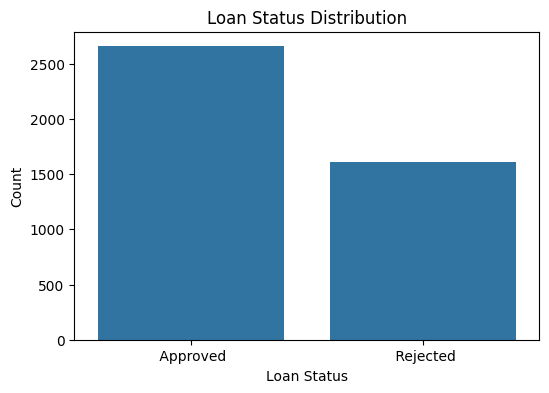

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df)
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()


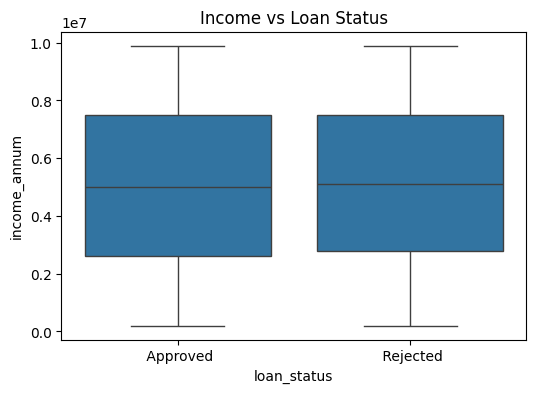

In [13]:
#income and loan comparision to understand relation
plt.figure(figsize=(6,4))
sns.boxplot(x='loan_status', y='income_annum', data=df)
plt.title('Income vs Loan Status')
plt.show()

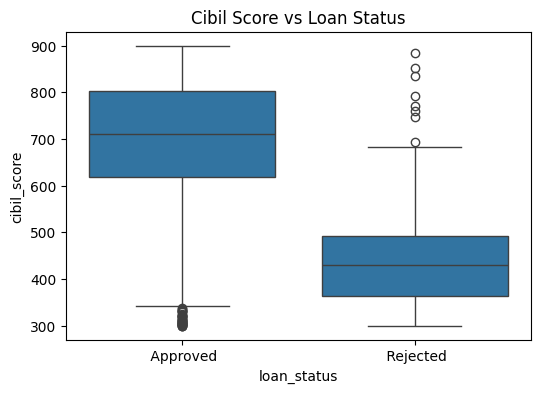

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x='loan_status', y='cibil_score', data=df)
plt.title('Cibil Score vs Loan Status')
plt.show()

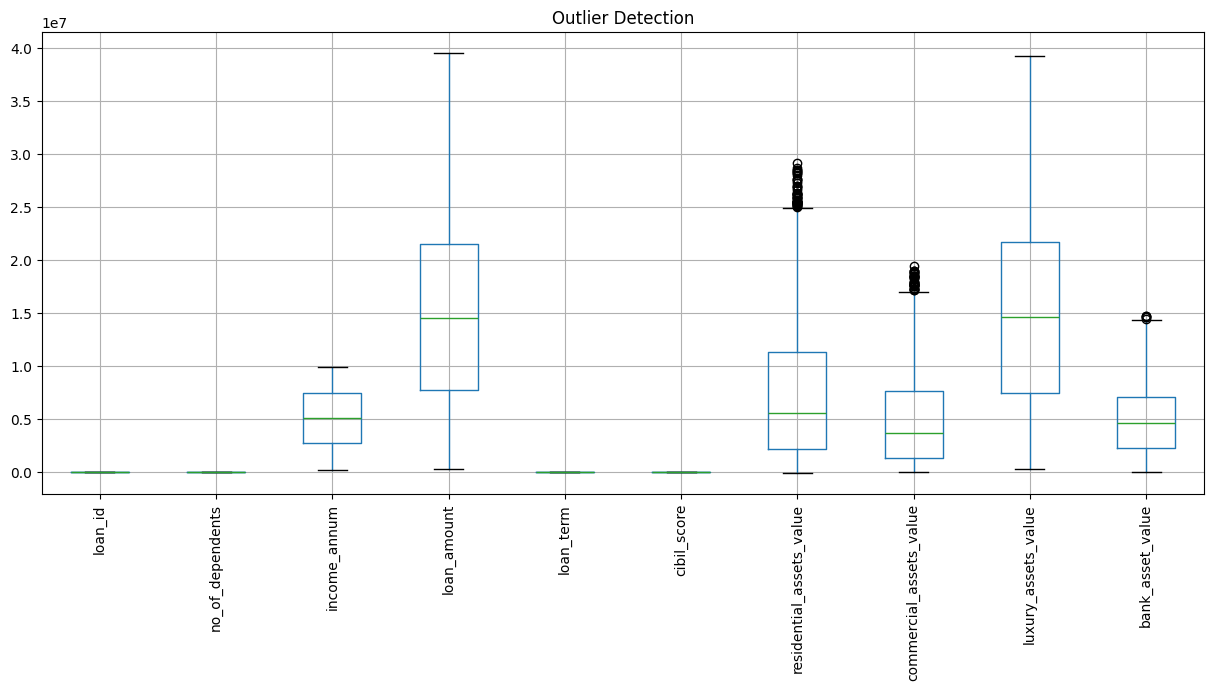

In [15]:
# detecting Outlier in  coloumns of integer type
int_cols = df.select_dtypes(
include='int'
)

plt.figure(
figsize=(15,6)
)

int_cols.boxplot()

plt.title(
"Outlier Detection"
)

plt.xticks(
rotation=90
)
plt.show()

In [16]:
#print the coloumns that contain outliers 

int_cols = df.select_dtypes(
include='int'
)

for col in int_cols.columns:

    Q1 = df[col].quantile(0.25)

    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower)
        |
        (df[col] > upper)
    ]

    if len(outliers) > 0:

        print(
            col,
            ":",
            len(outliers)
        )

residential_assets_value : 52
commercial_assets_value : 37
bank_asset_value : 5


In [17]:
#detection of outliers values 
# residential_assets_value

outliers = []

Q1 = df['residential_assets_value'].quantile(0.25)

Q3 = df['residential_assets_value'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

for value in df['residential_assets_value']:

    if value < lower or value > upper:

        outliers.append(
            value
        )

print(
"Outlier Values:"
)

print(
outliers
)

Outlier Values:
[25500000, 25900000, 26800000, 25500000, 25600000, 25400000, 28300000, 26300000, 27600000, 28700000, 25300000, 25800000, 25500000, 25300000, 28200000, 25200000, 25800000, 25700000, 25500000, 27000000, 28500000, 26300000, 28400000, 27000000, 25900000, 28500000, 26600000, 26200000, 28000000, 25800000, 25500000, 26900000, 25200000, 27600000, 25300000, 26100000, 29100000, 25400000, 28200000, 25100000, 25600000, 25400000, 26100000, 27500000, 25000000, 25500000, 25400000, 26200000, 25100000, 27400000, 27300000, 26200000]


In [18]:
#detection of outliers values 
# commercial_asset_value

outliers1 = []

Q1 = df['commercial_assets_value'].quantile(0.25)

Q3 = df['commercial_assets_value'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

for value in df['commercial_assets_value']:

    if value < lower or value > upper:

        outliers1.append(
            value
        )

print(
"Outlier Values:"
)

print(
outliers1
)

Outlier Values:
[17600000, 18700000, 17500000, 19000000, 17200000, 18500000, 18800000, 17800000, 18500000, 17900000, 18300000, 17300000, 17300000, 18900000, 18400000, 18200000, 17300000, 19000000, 19400000, 17800000, 17500000, 17900000, 17400000, 18500000, 17600000, 19000000, 17700000, 18800000, 18400000, 17200000, 18400000, 17700000, 18500000, 17600000, 17600000, 17900000, 17600000]


In [19]:
# commercial_asset_value

outliers2 = []

Q1 = df['bank_asset_value'].quantile(0.25)

Q3 = df['bank_asset_value'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

for value in df['bank_asset_value']:

    if value < lower or value > upper:

        outliers2.append(
            value
        )

print(
"Outlier Values:"
)

print(
outliers2
)

Outlier Values:
[14400000, 14700000, 14600000, 14600000, 14700000]


In [20]:
# Drop the loan_id column because it is just an identifier, not useful for prediction
if 'loan_id' in df.columns:
    df = df.drop('loan_id', axis=1)

print('Columns after dropping loan_id:')
print(df.columns)

Columns after dropping loan_id:
Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='str')


In [21]:
# clipping outlier to preserve data
#Outliers were clipped to reduce the influence of extreme values while preserving all observations in the dataset.

int_cols = df.select_dtypes(
include='int'
)
for col in int_cols.columns:
    Q1 = df[col].quantile(
        0.25
    )
    Q3 = df[col].quantile(
        0.75
    )
    IQR = Q3 - Q1
    lower = Q1 - (
        1.5 * IQR
    )
    upper = Q3 + (
        1.5 * IQR
    )
    df[col] = df[col].clip(
        lower,
        upper
    )
print(
"Outliers Clipped Successfully"
)

Outliers Clipped Successfully


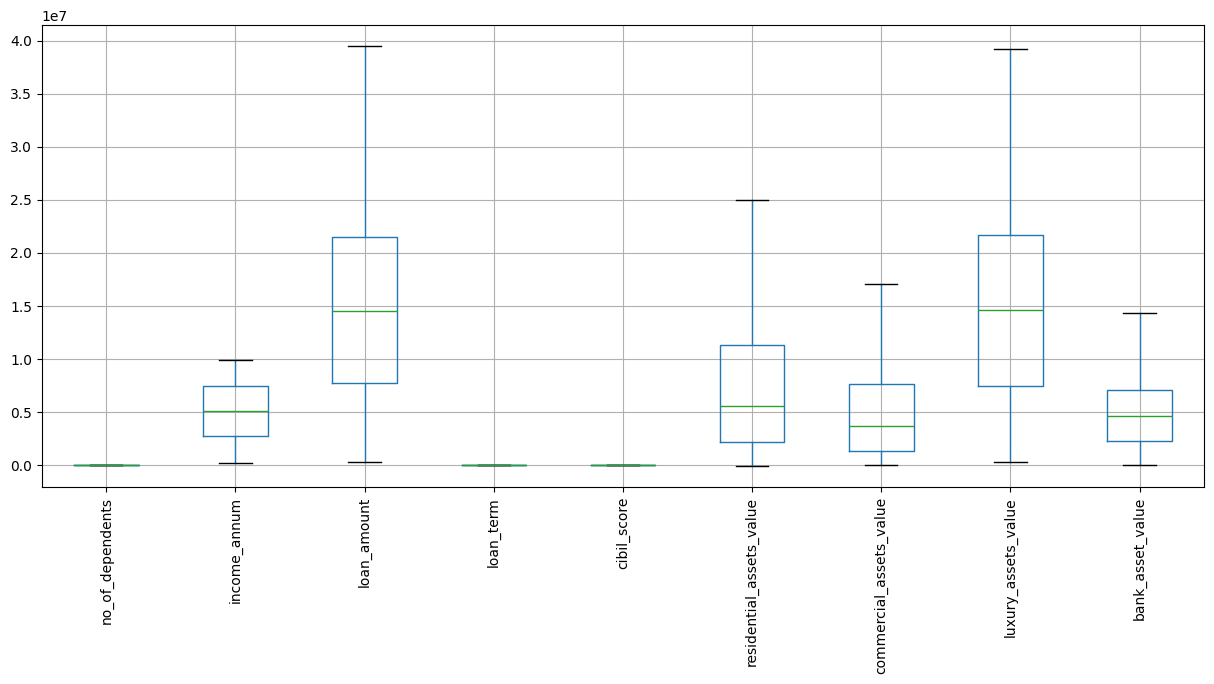

In [22]:
plt.figure(
figsize=(15,6)
)

df.select_dtypes(
include='int'
).boxplot()

plt.xticks(
rotation=90
)

plt.show()

In [23]:
# apply label encoding since dtype is either yes or no kindoff answers for string coloumn
le_edu = LabelEncoder()
le_se = LabelEncoder()
le_ls = LabelEncoder()

df['education'] = le_edu.fit_transform(df['education'])
df['self_employed'] = le_se.fit_transform(df['self_employed'])
df['loan_status'] = le_ls.fit_transform(df['loan_status'])

print('Education mapping:', dict(zip(le_edu.classes_, le_edu.transform(le_edu.classes_))))
print('Self_employed mapping:', dict(zip(le_se.classes_, le_se.transform(le_se.classes_))))
print('Loan_status mapping:', dict(zip(le_ls.classes_, le_ls.transform(le_ls.classes_))))

print('\nDataset after encoding:')

Education mapping: {' Graduate': np.int64(0), ' Not Graduate': np.int64(1)}
Self_employed mapping: {' No': np.int64(0), ' Yes': np.int64(1)}
Loan_status mapping: {' Approved': np.int64(0), ' Rejected': np.int64(1)}

Dataset after encoding:


In [24]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17050000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [25]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

print('X shape:', X.shape)
print('y shape:', y.shape)
print('\nFeature columns:', X.columns)


X shape: (4269, 11)
y shape: (4269,)

Feature columns: Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'],
      dtype='str')


In [26]:
# 80% data for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [27]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Y_train:", y_train.shape)
print("Y_test :", y_test.shape)

X_train: (3415, 11)
X_test : (854, 11)
Y_train: (3415,)
Y_test : (854,)


In [28]:
scaler = StandardScaler()

# Fit the scaler only on training data, then apply to both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Scaled training set shape:', X_train_scaled.shape)
print('Mean of first feature after scaling (should be ~0):', round(X_train_scaled[:, 0].mean(), 4))
print('Std of first feature after scaling (should be ~1):', round(X_train_scaled[:, 0].std(), 4))


Scaled training set shape: (3415, 11)
Mean of first feature after scaling (should be ~0): -0.0
Std of first feature after scaling (should be ~1): 1.0


In [29]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# CV on the SAME data the final model is trained on
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print('Mean CV Accuracy:', round(cv_scores.mean() * 100, 2), '%')
print('Std:', round(cv_scores.std() * 100, 2), '%')


Mean CV Accuracy: 97.86 %
Std: 0.15 %


In [42]:
# Hyperparameter testing using GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print('Best parameters:', grid_search.best_params_)
print('Best CV accuracy:', round(grid_search.best_score_ * 100, 2), '%')


Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
Best CV accuracy: 98.01 %


In [49]:
# Train final model with best hyperparameters
best_params = grid_search.best_params_

rf_model = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    max_features=best_params['max_features'],
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)

# Prediction
y_pred = rf_model.predict(X_test_scaled)


In [50]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

print(classification_report(y_test, y_pred, target_names=["Rejected", "Approved"]))


Accuracy: 97.78 %
              precision    recall  f1-score   support

    Rejected       0.98      0.99      0.98       536
    Approved       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854



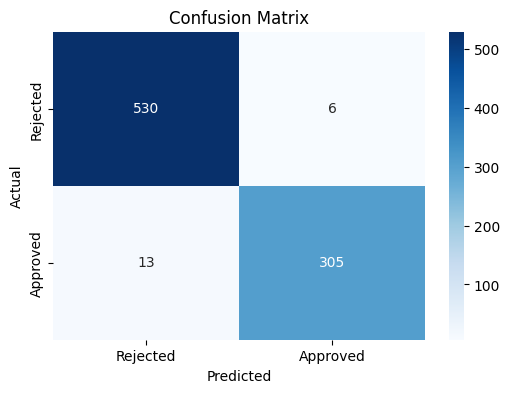

In [51]:
# Confusion Matrix heatmap
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


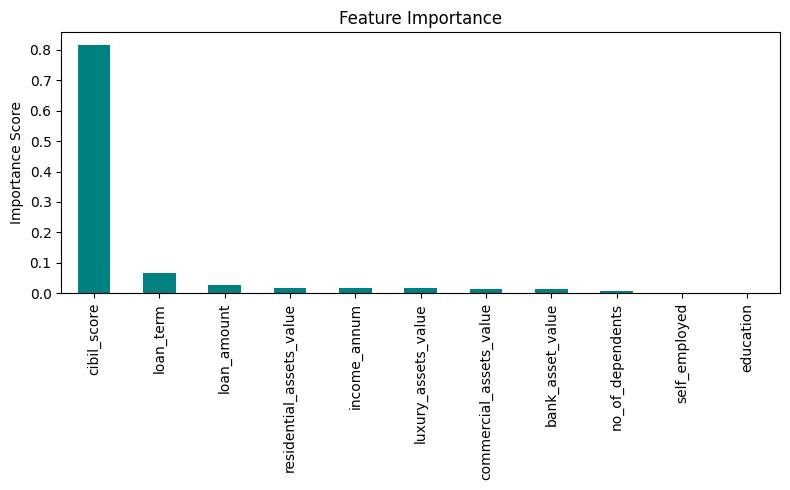

cibil_score                 0.816872
loan_term                   0.064755
loan_amount                 0.027669
residential_assets_value    0.017199
income_annum                0.017075
luxury_assets_value         0.016696
commercial_assets_value     0.015059
bank_asset_value            0.013800
no_of_dependents            0.006981
self_employed               0.002092
education                   0.001801
dtype: float64


In [52]:
# Feature importance
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance.plot(kind='bar', color='teal')
plt.title('Feature Importance')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

print(importance)


In [53]:
# Save the trained model and the scaler
import joblib

joblib.dump(rf_model, 'loan_approval_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print('Model saved as loan_approval_model.pkl')
print('Scaler saved as scaler.pkl')


Model saved as loan_approval_model.pkl
Scaler saved as scaler.pkl
